# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- State extraction
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: Nautilus_trader
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\Nautilus_trader.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\Nautilus_trader.sqlite
Closed event type id: 2071


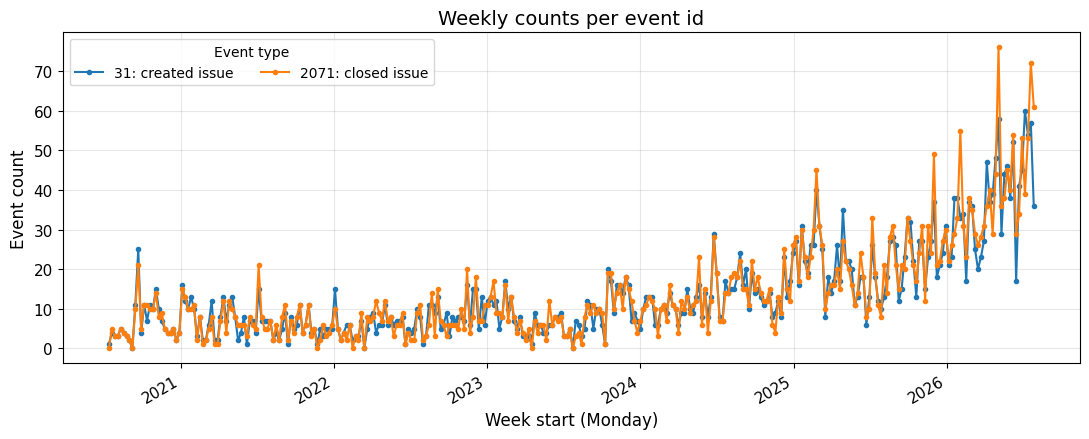

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Nautilus_trader\weekly_open_closed_summary.csv


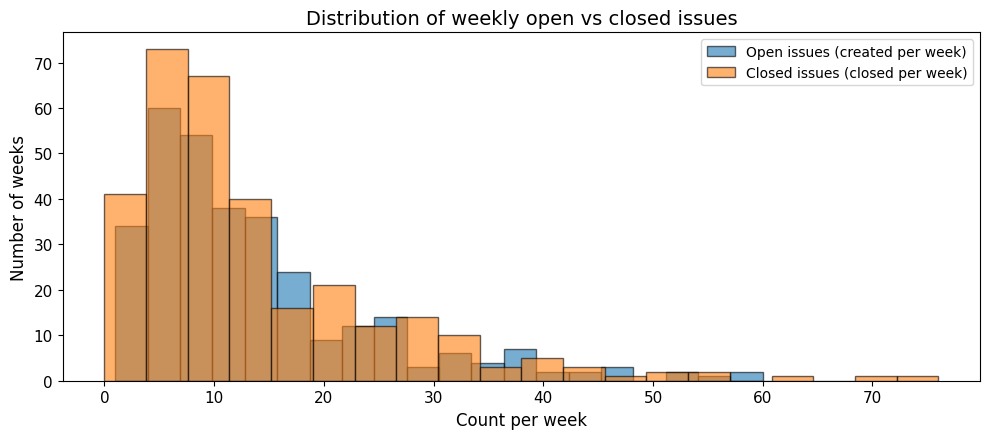

,Open issues (weekly created),Closed issues (weekly closed)
count,313.00,313.00
mean,13.48,13.69
std,11.23,12.10
min,1.00,0.00
25%,6.00,6.00
50%,10.00,10.00
75%,17.00,18.00
max,60.00,76.00


In [1]:
from pathlib import Path

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("Nautilus_trader")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR + lexicon state extraction


In [2]:
from functions.anomaly_pipeline import run_anomaly_state_extraction

weekly_closed_anomaly_frame, anomaly_context, anomaly_states, event_closed_title_join = (
    run_anomaly_state_extraction(weekly, eventsPerobj_df, objects_attributes, cfg)
)
anomaly_states.head()


Detected 19 rolling-IQR anomalies for event_type_id=2071.
Joined title attribute rows: 4286 of 4286 event rows.
Saved anomaly states to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Nautilus_trader\anomaly_states.csv


,week_start,value,is_anomaly,anomaly_direction,anomaly_score,lower_bound,upper_bound,title_count,event_count,severity,component,reasoning,extraction_method,confidence,event_descriptions,titles_in_week
0,2020-09-14,10,True,high,2.333333,0.50,6.50,8,10,P2,build & ci,Weekly closures show a clearly beyond-typical ...,rule_based,0.642500,"[closed (#35), closed (#28), closed (#26), clo...","[Remove pre-release, MaxBidMinAsk, Develop, Co..."
1,2020-09-21,21,True,high,6.500000,0.00,8.00,14,21,P3,testing,Weekly closures show a well beyond-typical spi...,rule_based,0.837500,"[closed (#54), closed (#53), closed (#48), clo...","[Test position.unrealized_pnl, Develop, Rework..."
2,2020-10-05,11,True,high,1.500000,0.00,8.00,6,11,P2,runtime stability,Weekly closures show a clearly beyond-typical ...,rule_based,0.902500,"[closed (#69), closed (#66), closed (#74), clo...",[ExecutionEngine now handles position flipping...
3,2021-07-05,21,True,high,0.590909,-4.25,17.75,21,21,P3,testing,Weekly closures show a slightly beyond-typical...,rule_based,0.928918,"[closed (#372), closed (#231), closed (#248), ...","[Convert analysis tests to pytest, Network sub..."
4,2021-11-22,0,True,low,0.166667,0.50,12.50,0,0,P4,unknown area,Weekly closures show a near-typical drop (0 vs...,rule_based,0.300000,[],[]


## 3. Export anomaly object / event IDs


In [3]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(anomaly_context, cfg)
anomaly_object_ids.head()



,week_start,object_id
0,2020-09-14,375233
1,2020-09-14,375262
2,2020-09-14,375299
3,2020-09-14,375456
4,2020-09-14,375500


## 4. Anomaly plots


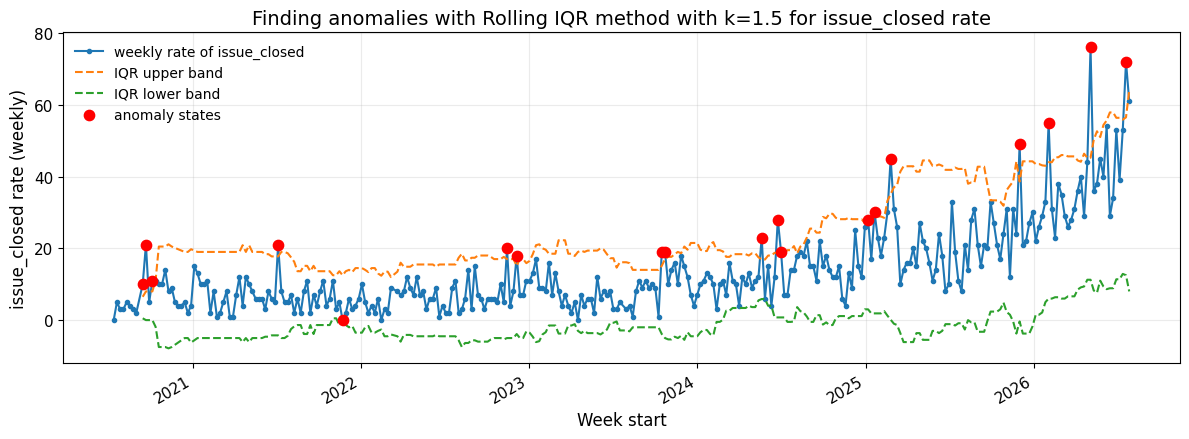

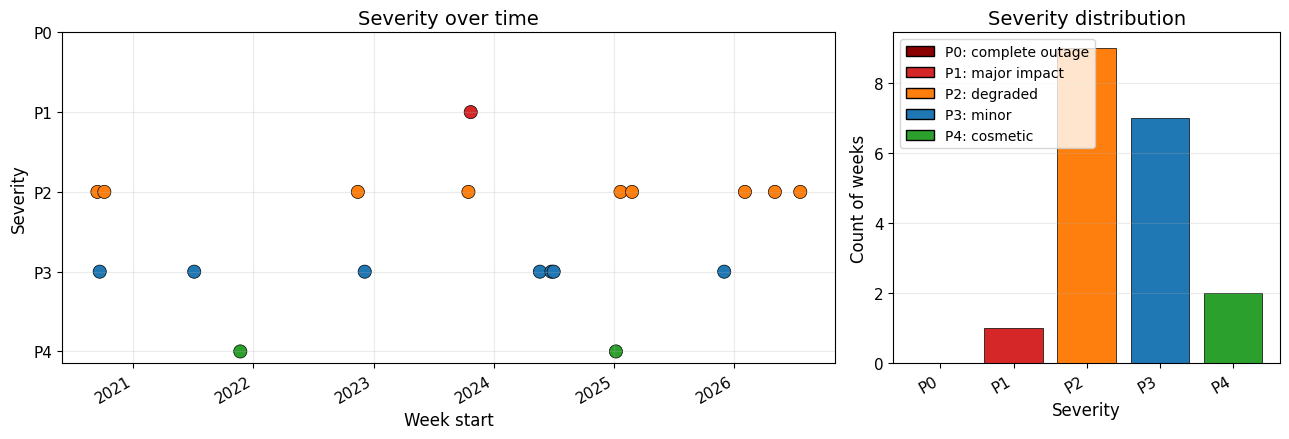

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:397: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 1])


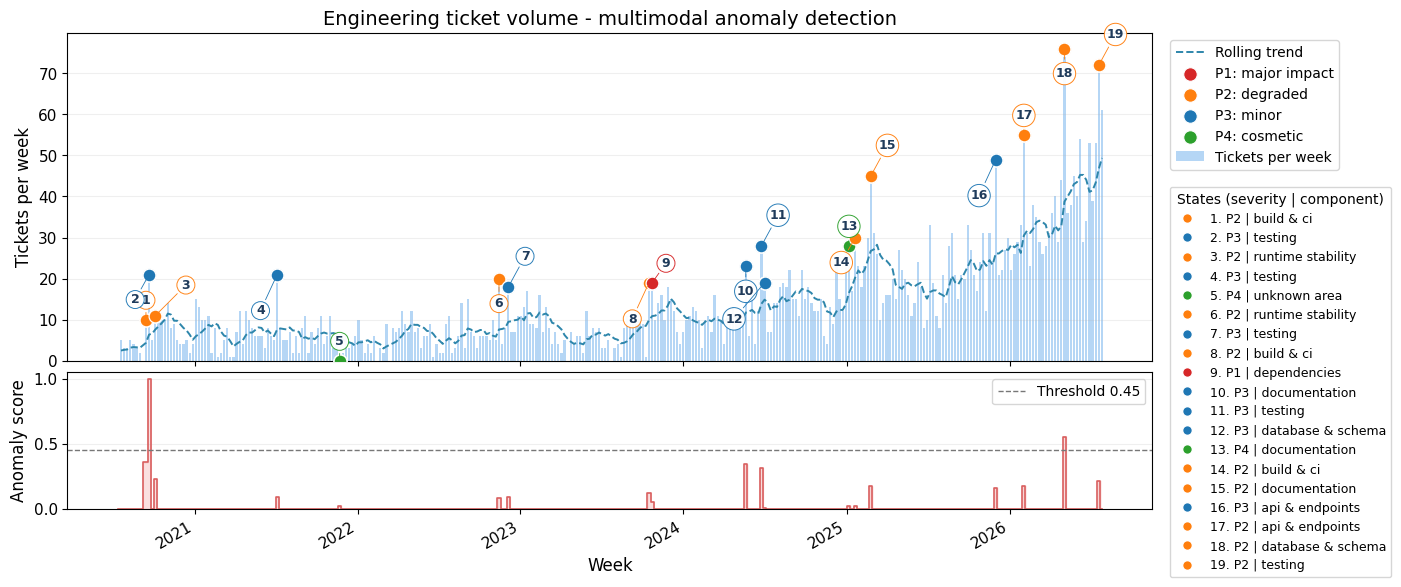

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:512: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 0.985])


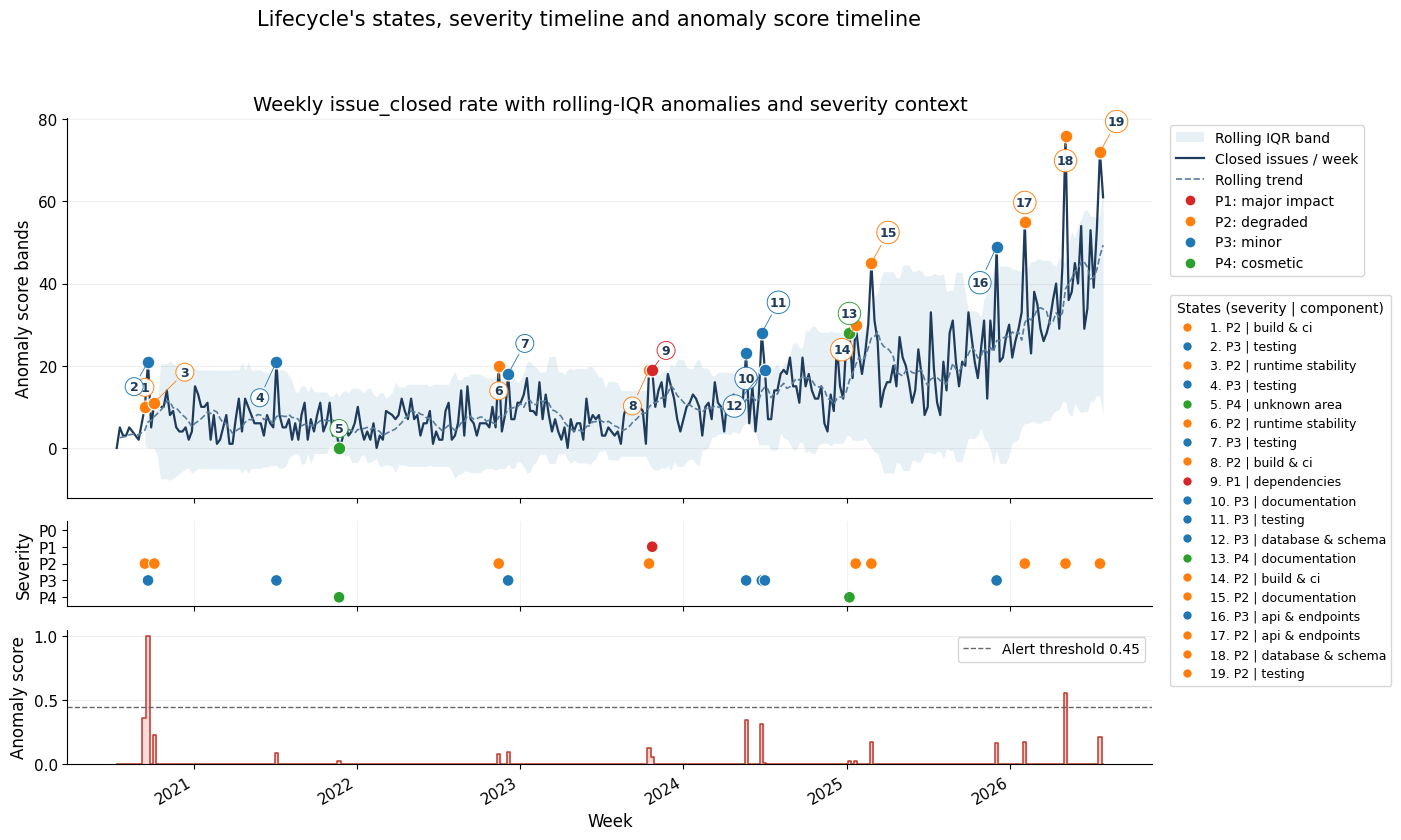

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/Nautilus_trader')

In [4]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(weekly_closed_anomaly_frame, anomaly_states, cfg)


## 5. Commit context and type classification


In [ ]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join = build_commit_context(
    weekly_closed_anomaly_frame, eventsPerobj_df, objects_attributes, cfg
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log


In [6]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 67317 events, 4220 cases
  case:concept:name concept:name            time:timestamp
0            100134      created 2025-10-28 07:28:44+00:00
1            100134      labeled 2025-10-28 07:28:45+00:00
2            100134      renamed 2025-10-29 09:52:01+00:00
3            100134    commented 2025-10-31 02:41:11+00:00
4            100134    mentioned 2025-10-31 02:41:12+00:00
5            100134   subscribed 2025-10-31 02:41:12+00:00
6            100134    commented 2025-10-31 21:45:24+00:00
7            100134       closed 2025-10-31 21:45:24+00:00
8            100171      created 2025-10-27 16:50:36+00:00
9            100171      labeled 2025-10-27 16:50:38+00:00


## 7. Vitalizing subset from anomaly object IDs


In [7]:
from functions.ocel_flatten import build_vitalizing_subset

anomaly_events_df, anomaly_df = build_vitalizing_subset(flat, anomaly_object_ids)


Anomaly events df: 7261 rows, 550 cases


## 8. Preprocess + random control (MAX_REP / SEED unchanged)


In [8]:
from functions.preprocessing import build_preprocessed_logs

prep = build_preprocessed_logs(flat, anomaly_events_df, cfg)
flat_df_clean = prep["flat_df_clean"]
vitalizing_df_clean = prep["vitalizing_df_clean"]
random_case_control_df_clean = prep["random_case_control_df_clean"]
clean_log_groups_df = prep["clean_log_groups_df"]
all_cases_clean = prep["all_cases_clean"]
num_vital_cases_clean = prep["num_vital_cases_clean"]


=== Repetition cleaning summary (MAX_REP = 5) ===
Vitalizing: 274 -> 229 cases | 3641 -> 1825 events
Whole: 2335 -> 1798 cases | 38409 -> 14540 events
Random control (rebuilt): 229 cases | 1848 events


## 9. Discovery F1 evaluation on clean logs


In [9]:
from functions.discovery import evaluate_clean_logs

consolidated_results_table_clean, clean_log_groups_eventlog, miners = evaluate_clean_logs(
    clean_log_groups_df, cfg
)
consolidated_results_table_clean.head()


c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 168/168 [00:00<00:00, 603.32it/s]


Expected records: 51 | Observed: 51

7) Consolidated results table in clean logs
               log_name             discovery_method  distinct_traces  \
0   random_case_control                alpha_classic              168   
1            vitalizing                alpha_classic              162   
2                 whole                alpha_classic              963   
3   random_case_control           heuristics_dep_0.5              168   
4            vitalizing           heuristics_dep_0.5              162   
5                 whole           heuristics_dep_0.5              963   
6   random_case_control           heuristics_dep_0.6              168   
7            vitalizing           heuristics_dep_0.6              162   
8                 whole           heuristics_dep_0.6              963   
9   random_case_control           heuristics_dep_0.7              168   
10           vitalizing           heuristics_dep_0.7              162   
11                whole           heuristic

,log_name,discovery_method,distinct_traces,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,random_case_control,alpha_classic,168,0.682593,0.542620,0.208816,0.301576,198.0,51.0,0.253333,ok,None
1,vitalizing,alpha_classic,162,0.636737,0.597227,0.142493,0.230088,65.0,4.0,1.000000,ok,None
2,whole,alpha_classic,963,0.724026,0.493709,0.132202,0.208558,95.0,13.0,1.000000,ok,None
3,random_case_control,heuristics_dep_0.5,168,0.456793,0.845958,0.433596,0.573331,602.0,43.0,0.452055,ok,None
4,vitalizing,heuristics_dep_0.5,162,0.457555,0.824606,0.414666,0.551834,667.0,48.0,0.460714,ok,None


## 10. Utility figures


Plotting from 51 successful rows
Miner configs: ['alpha_classic', 'heuristics_dep_0.5', 'heuristics_dep_0.6', 'heuristics_dep_0.7', 'inductive_IM', 'inductive_IMf_noise_0.2', 'inductive_IMf_noise_0.3', 'inductive_IMf_noise_0.4', 'split_miner_eps_0.1_eta_0.4', 'split_miner_eps_0.1_eta_0.5', 'split_miner_eps_0.1_eta_0.6', 'split_miner_eps_0.2_eta_0.4', 'split_miner_eps_0.2_eta_0.5', 'split_miner_eps_0.2_eta_0.6', 'split_miner_eps_0.3_eta_0.4', 'split_miner_eps_0.3_eta_0.5', 'split_miner_eps_0.3_eta_0.6']
Log groups: ['random_case_control', 'vitalizing', 'whole']
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Nautilus_trader\clean_log_f_score_grouped_bars.{png,pdf}


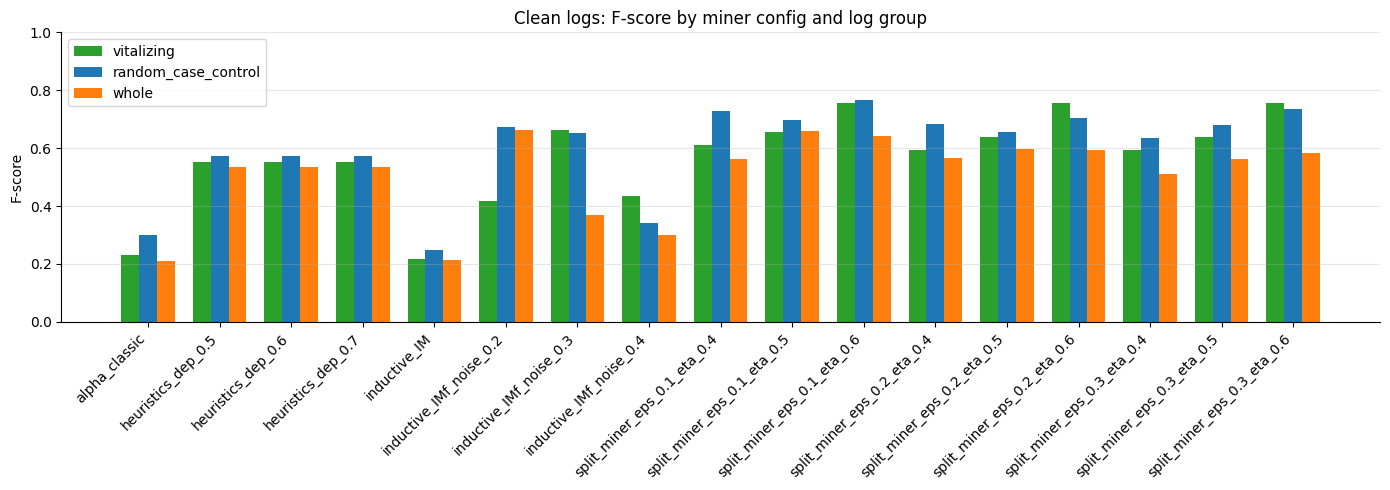

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Nautilus_trader\clean_log_fitness_precision.{png,pdf}


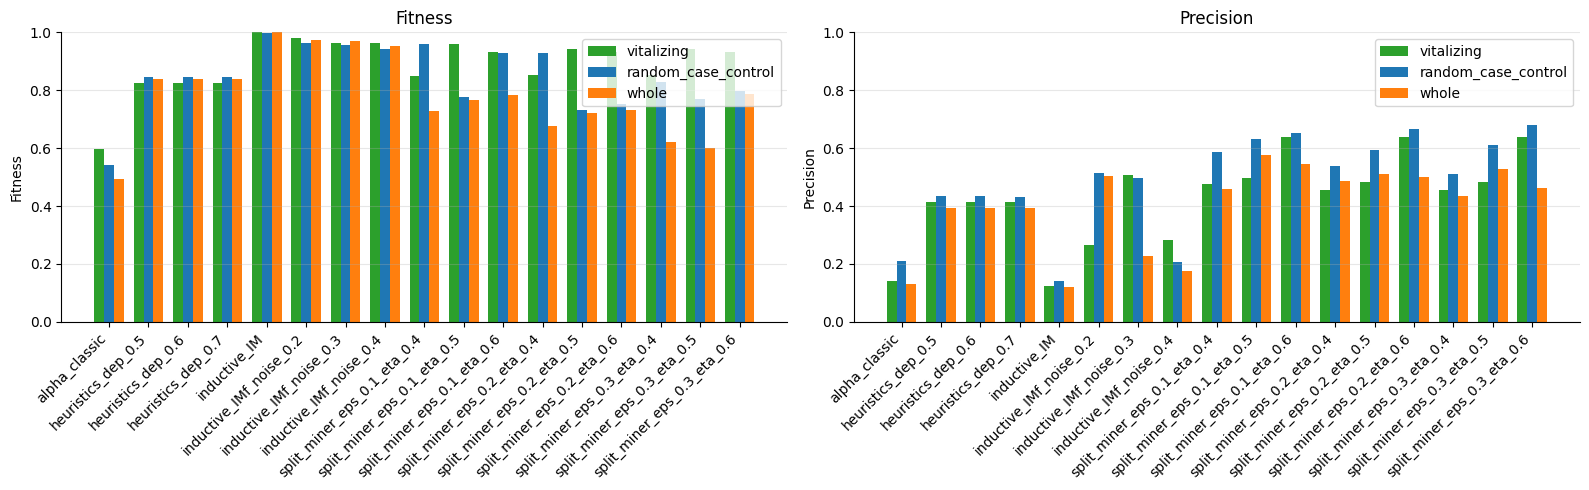

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Nautilus_trader\clean_log_complexity.{png,pdf}


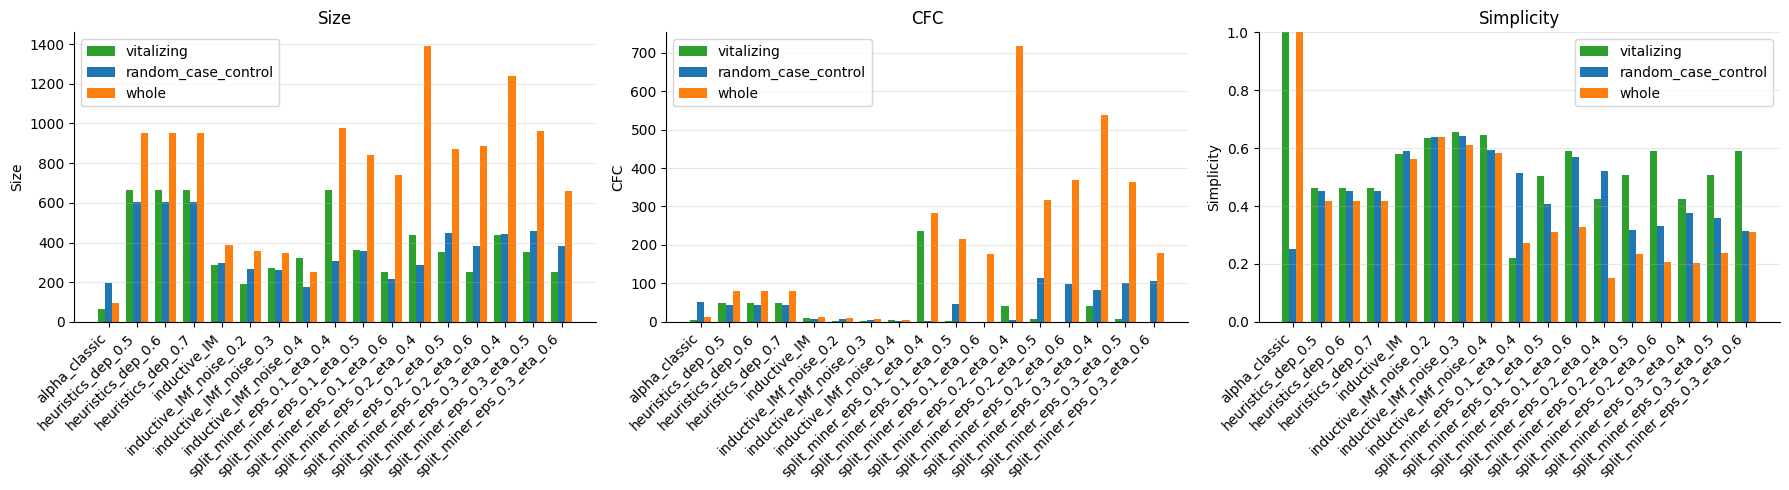

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Nautilus_trader\clean_log_threshold_sensitivity.{png,pdf}


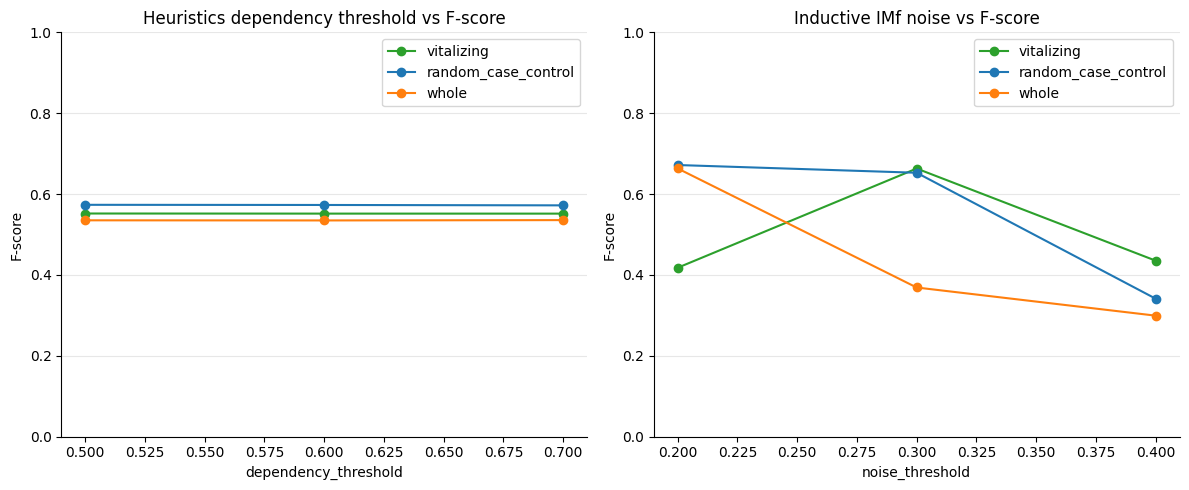

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Nautilus_trader\clean_log_f_score_slopegraph.{png,pdf}


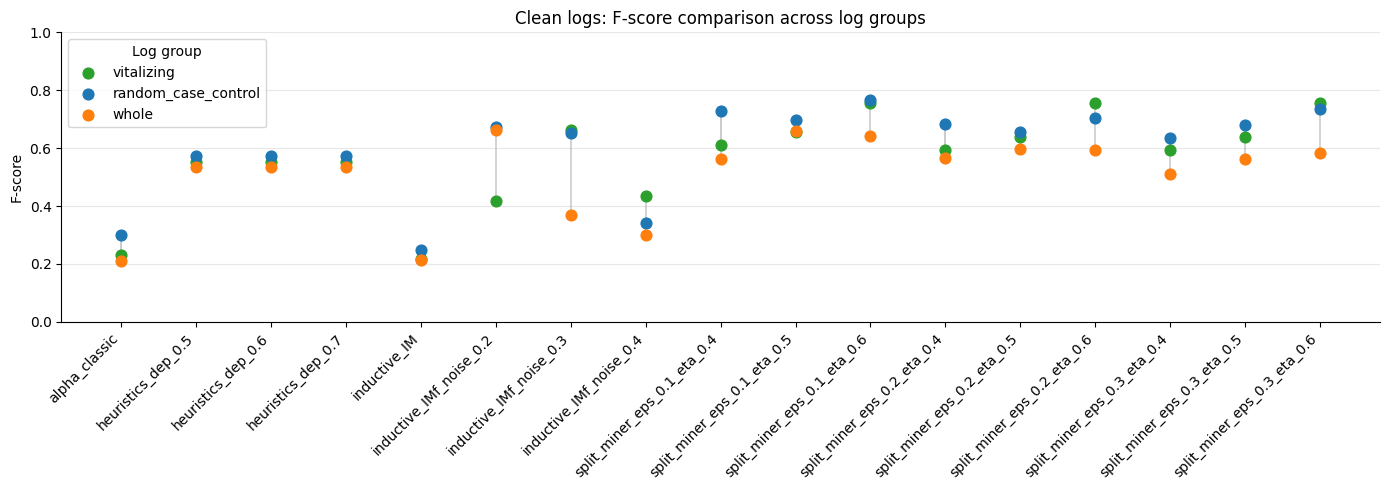

{'wide_f_score_clean': discovery_method     alpha_classic  heuristics_dep_0.5  heuristics_dep_0.6  \
 log_name                                                                     
 random_case_control       0.301576            0.573331            0.572940   
 vitalizing                0.230088            0.551834            0.551573   
 whole                     0.208558            0.534987            0.534680   
 
 discovery_method     heuristics_dep_0.7  inductive_IM  \
 log_name                                                
 random_case_control            0.571990      0.249897   
 vitalizing                     0.551531      0.218282   
 whole                          0.535483      0.215220   
 
 discovery_method     inductive_IMf_noise_0.2  inductive_IMf_noise_0.3  \
 log_name                                                                
 random_case_control                 0.671764                 0.652623   
 vitalizing                          0.417646                 0.663

In [10]:
from functions.plotting_utility import plot_utility_figures

plot_utility_figures(consolidated_results_table_clean, cfg)


## 11. Seed reproducibility


replaying log with TBR, completed traces :: 100%|██████████| 167/167 [00:00<00:00, 826.68it/s]


Reproducibility over 10 seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Discovery metrics summary (mean/std/CV per miner):
               discovery_method  fitness_mean  fitness_std  fitness_cv  \
0                 alpha_classic      0.547483     0.055223    0.100867   
1            heuristics_dep_0.5      0.832657     0.017370    0.020861   
2            heuristics_dep_0.6      0.832029     0.017412    0.020928   
3            heuristics_dep_0.7      0.832899     0.017657    0.021199   
4                  inductive_IM      0.995577     0.009300    0.009342   
5       inductive_IMf_noise_0.2      0.967821     0.014200    0.014672   
6       inductive_IMf_noise_0.3      0.950578     0.035075    0.036899   
7       inductive_IMf_noise_0.4      0.942734     0.016602    0.017611   
8   split_miner_eps_0.1_eta_0.4      0.795880     0.092974    0.116820   
9   split_miner_eps_0.1_eta_0.5      0.810238     0.090494    0.111689   
10  split_miner_eps_0.1_eta_0.6      0.845297     0.059619    0.070530  

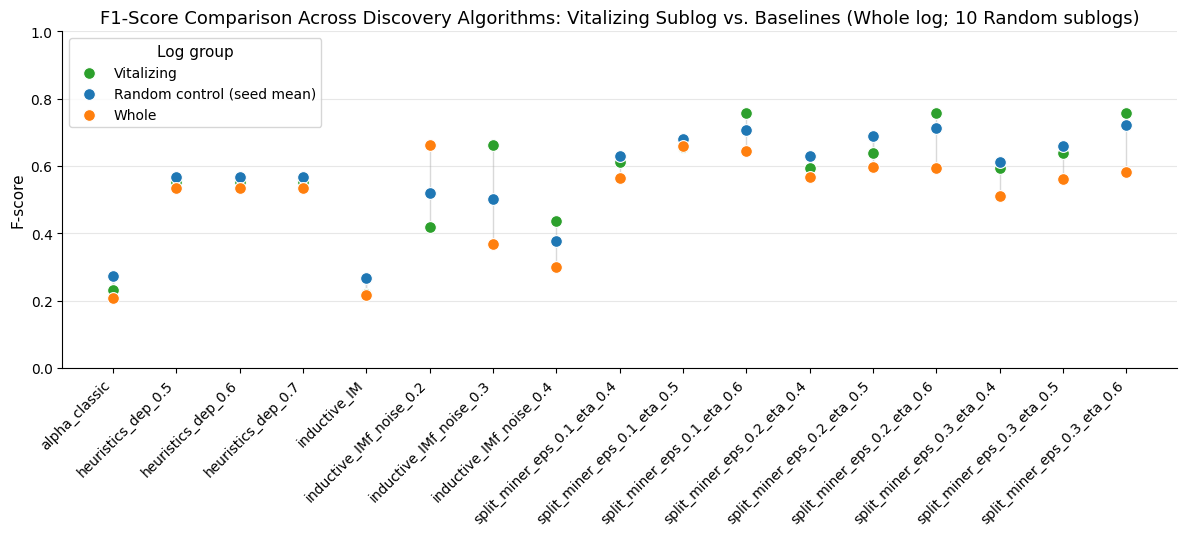

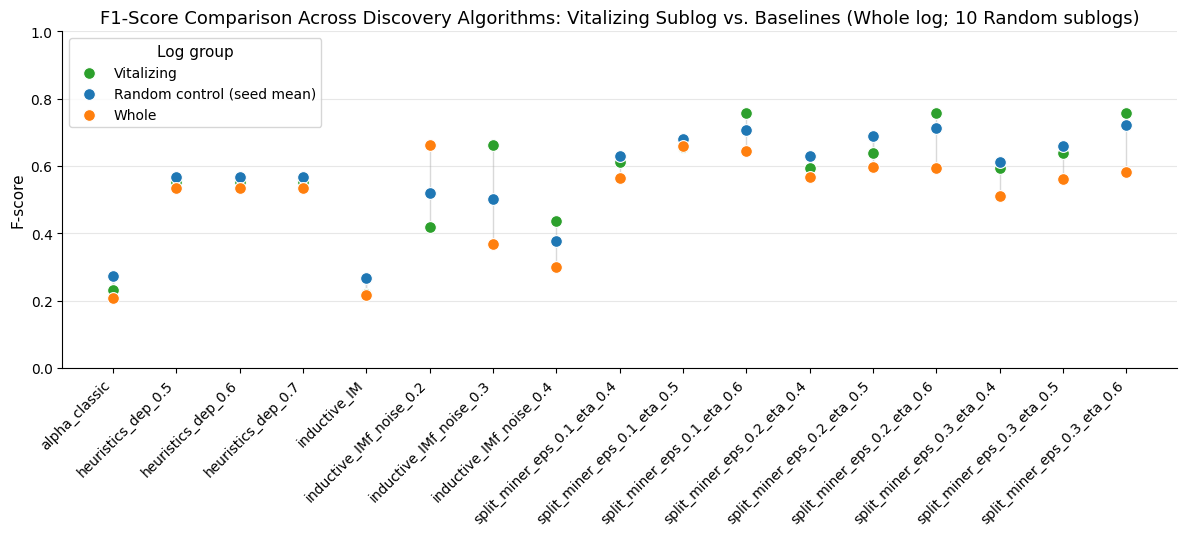

In [11]:
from functions.plotting_utility import plot_repro_slopegraph
from functions.reproducibility import run_seed_reproducibility

repro = run_seed_reproducibility(
    flat_df_clean=flat_df_clean,
    all_cases_clean=all_cases_clean,
    num_vital_cases_clean=num_vital_cases_clean,
    miners=miners,
    consolidated_results_table_clean=consolidated_results_table_clean,
    cfg=cfg,
)
consolidated_results_table_clean_repro = repro["consolidated_results_table_clean_repro"]
plot_repro_slopegraph(consolidated_results_table_clean_repro, cfg)
